##Importamos Librerias

In [27]:
import pandas as pd

In [28]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

## CARGAMOS UN ARCHIVO CSV CYBERSECURITY_INTRUSION EN UN AVARIABLE dfo

In [4]:
dfo = pd.read_csv("cybersecurity_intrusion_data.csv")

## CONTENIDO DEL DATAFRAME EN LA VARIABLE dfo

In [5]:
dfo


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


In [6]:
dfo.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 819.7 KB


## array muestra que tienes 5 categorías distintas en esa columna: Edge, Firefox, Chrome, Safari y una etiqueta 'Unknown' para casos no identificados.

In [7]:
dfo['browser_type'].unique()
np.array(['Edge', 'Firefox', 'Chrome', 'Unknown', 'Safari'], dtype=str)


array(['Edge', 'Firefox', 'Chrome', 'Unknown', 'Safari'], dtype='<U7')

## MOSTRAMOS CUALES SON LOS NAVEGADORES MAS UTILIZADOS / Desconocido O Unknown : Podría ser un indicador de scripts automatizados o bots. ## Series donde el índice son los tipos de navegadores y los valores son la cantidad de veces que aparecen.

In [8]:
dfo.groupby('browser_type').size()

browser_type
Chrome     5137
Edge       1469
Firefox    1944
Safari      485
Unknown     502
dtype: int64

ELIMINA DUPLICADOS Y REEMPLAZAR INFINITOS COMO NULOS Y LUEGO LO VOLVEMOS A ELIMINAR

In [9]:
# Drop rows with missing values

dfo = dfo.dropna()

# Replace inf/-inf with NaN, then drop or replace them
dfo = dfo.replace([np.inf, -np.inf], np.nan).dropna()
dfo.dropna()


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9528,SID_09529,535,TCP,7,50.518476,DES,0.767659,1,Edge,1,1
9531,SID_09532,746,TCP,7,315.151758,DES,0.190059,3,Chrome,0,1
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0


## COMPROBACION QUE YA NO TENEMOS VALORES NULOS

In [10]:
dfo.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Resumen completo y que tipo son cada una de las columnas

In [11]:
dfo.info()

<class 'pandas.DataFrame'>
Index: 7571 entries, 0 to 9535
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           7571 non-null   str    
 1   network_packet_size  7571 non-null   int64  
 2   protocol_type        7571 non-null   str    
 3   login_attempts       7571 non-null   int64  
 4   session_duration     7571 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  7571 non-null   float64
 7   failed_logins        7571 non-null   int64  
 8   browser_type         7571 non-null   str    
 9   unusual_time_access  7571 non-null   int64  
 10  attack_detected      7571 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 709.8 KB


In [12]:
dfo['intruso'] = dfo['browser_type'].apply(lambda x: 0 if x == 'Chrome' else 1)
# dfo = dfo.drop('browser_type', axis=1)
print(dfo['intruso'].value_counts())

intruso
0    4082
1    3489
Name: count, dtype: int64


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

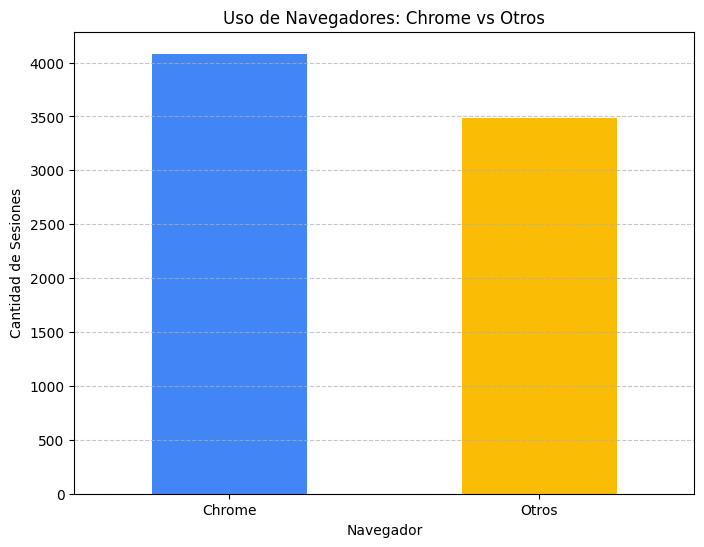

In [15]:
# 1. Creamos una nueva columna para agrupar los navegadores
# Si es 'Chrome' se queda igual, si no, lo marcamos como 'Otros'
dfo['browser_group'] = dfo['browser_type'].apply(lambda x: 'Chrome' if x == 'Chrome' else 'Otros')

# 2. Contamos cuántos hay de cada grupo
counts = dfo['browser_group'].value_counts()

# 3. Graficamos
plt.figure(figsize=(8, 6))
counts.plot(kind='bar', color=['#4285F4', '#FBBC05']) # Colores tipo Google

plt.title('Uso de Navegadores: Chrome vs Otros')
plt.xlabel('Navegador')
plt.ylabel('Cantidad de Sesiones')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Mapa de calor (heat map) que analiza la "Concentración de Sesiones" 
## Dominio de Chrome: Existe una concentración masiva de 4,082 sesiones donde tanto el eje vertical como el horizontal coinciden en "Chrome". Es, por mucho, el valor más alto del gráfico.
## Categoría "Otros": En el eje vertical, cuando el navegador se clasifica como "Otros", la distribución en el eje horizontal es más variada:
## Firefox: 1,527 sesiones.
## Edge: 1,183 sesiones.
## Safari: 382 sesiones.
## Unknown (Desconocido): 397 sesiones.

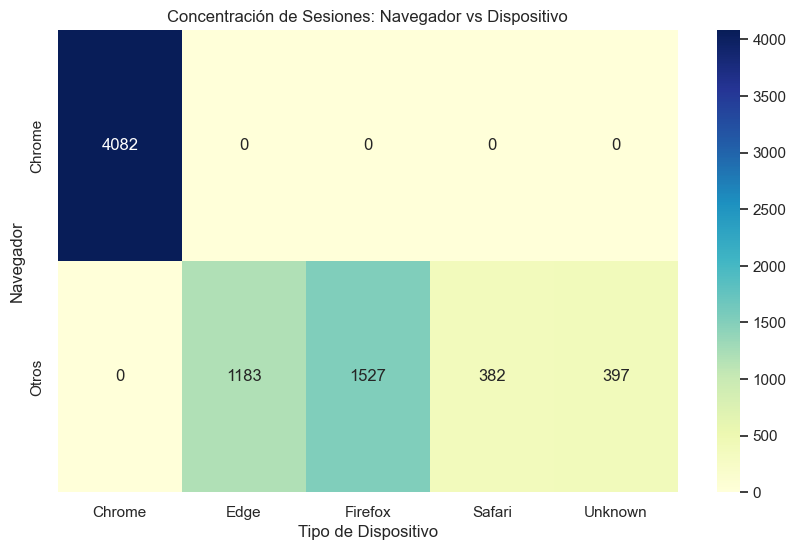

In [ ]:
# 1. Creamos la tabla cruzada (Pivot Table)
# Suponiendo que tienes una columna 'device_type' 
heatmap_data = dfo.groupby(['browser_group', 'browser_type']).size().unstack(fill_value=0)

# 2. Graficamos
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Concentración de Sesiones: Navegador vs Dispositivo')
plt.xlabel('Tipo de Dispositivo')
plt.ylabel('Navegador')
plt.show()


##YA TENEMEMOS CREADO NUESTRA NUEVA COLUMNA BROWSER_GROUP

In [17]:
dfo.info()

<class 'pandas.DataFrame'>
Index: 7571 entries, 0 to 9535
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           7571 non-null   str    
 1   network_packet_size  7571 non-null   int64  
 2   protocol_type        7571 non-null   str    
 3   login_attempts       7571 non-null   int64  
 4   session_duration     7571 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  7571 non-null   float64
 7   failed_logins        7571 non-null   int64  
 8   browser_type         7571 non-null   str    
 9   unusual_time_access  7571 non-null   int64  
 10  attack_detected      7571 non-null   int64  
 11  intruso              7571 non-null   int64  
 12  browser_group        7571 non-null   str    
dtypes: float64(2), int64(6), str(5)
memory usage: 828.1 KB


## SEGUN ALALISIS SE PUEDE DETERMINAR QUE A PESAR DE QUE EL NAVEGADOR CHROME ES EL MAS UTILZADO NO ES EL TIENE LAS SECIONES CON MAS TIEMPO, SIENDO OTROS NAVEGARDRES LOS DE MAYOR USO EN CUANTOS A SECCIONES.

In [30]:
df0 = pd.read_csv('cybersecurity_intrusion_data.csv') 

# 2. Agrupar por navegador y calcular la media de la duración
promedio_duracion = dfo.groupby('browser_type')['session_duration'].mean()

# 3. Mostrar el resultado
print("Promedio de duración por navegador:")
print(promedio_duracion)

Promedio de duración por navegador:
browser_type
Chrome     791.846144
Edge       768.040176
Firefox    789.135691
Safari     812.621894
Unknown    805.323774
Name: session_duration, dtype: float64


## Safari tiene la duración promedio de sesión más alta (812.62).
## Edge presenta el promedio más bajo (768.04).
## Los navegadores Chrome, Firefox y la categoría Unknown mantienen promedios muy similares entre sí, rondando los 790-805 segundos.
## Estos datos son útiles en ciberseguridad para identificar patrones de comportamiento normales; por ejemplo, una desviación extrema en la duración de sesión en un navegador específico ## podría indicar una anomalía o un intento de intrusión automatizado.

C:\Users\Rivera\AppData\Local\Temp\ipykernel_16228\1071820698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='browser_type', y='session_duration', data=df0, palette='viridis')


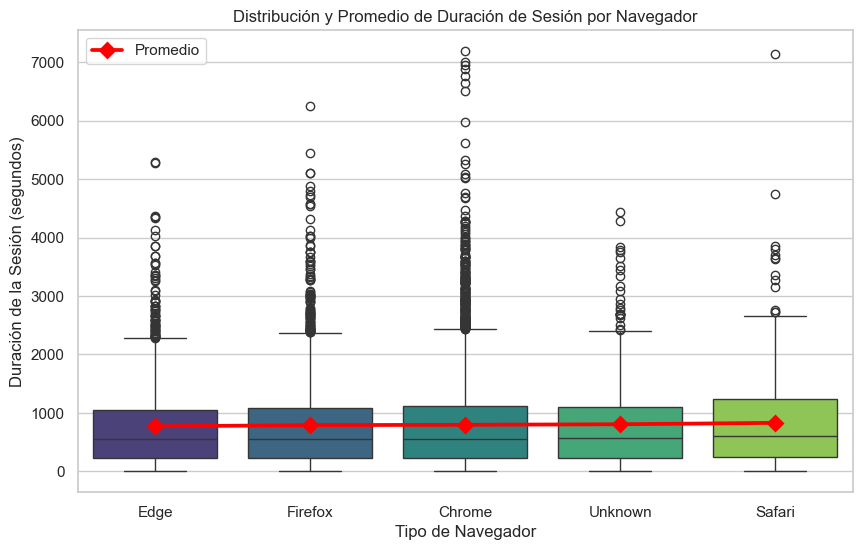

In [31]:
# 1. Configurar el estilo y tamaño de la gráfica
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Crear el boxplot
# Usamos el DataFrame original 'df0' para ver la dispersión completa
ax = sns.boxplot(x='browser_type', y='session_duration', data=df0, palette='viridis')

# 3. Añadir los puntos del promedio (opcional pero recomendado)
# Esto mostrará físicamente dónde cae la media que calculaste antes
sns.pointplot(x='browser_type', y='session_duration', data=df0, 
              estimator='mean', color='red', markers='D', label='Promedio')

# 4. Personalizar etiquetas
plt.title('Distribución y Promedio de Duración de Sesión por Navegador')
plt.xlabel('Tipo de Navegador')
plt.ylabel('Duración de la Sesión (segundos)')

plt.show()


## el boxplot te permitirá ver:
## La dispersión: Qué tan variadas son las sesiones en cada navegador.
## Valores atípicos (Outliers): Puntos fuera de los "bigotes" que podrían representar ataques o errores en el sistema.
## La mediana: La línea central dentro de la caja, que te dirá si los datos están sesgados.

C:\Users\Rivera\AppData\Local\Temp\ipykernel_16228\4143537581.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='browser_type', y='session_duration', data=df_filtrado, palette='Set2')


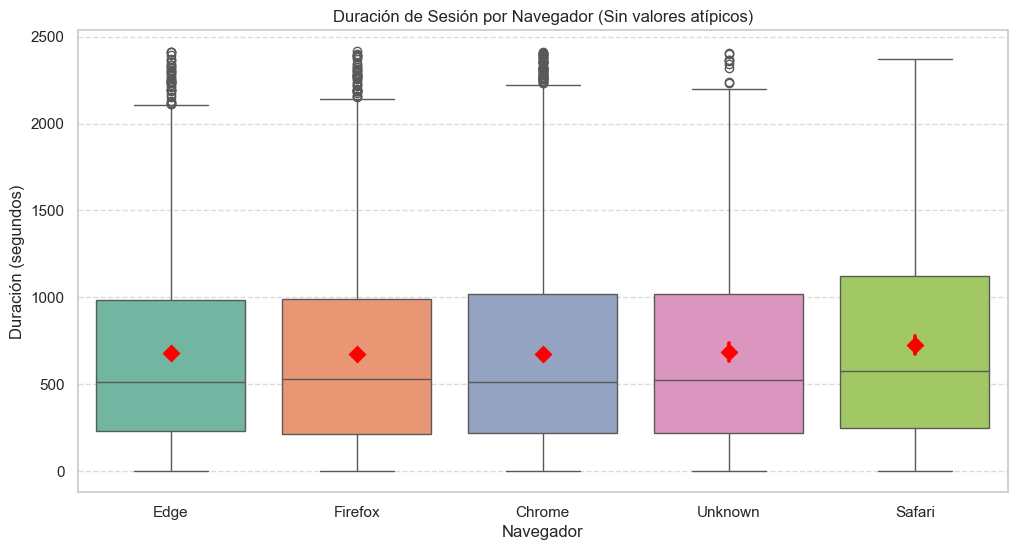

In [32]:
# 1. Calcular el IQR para filtrar valores atípicos (Outliers)
Q1 = df0['session_duration'].quantile(0.25)
Q3 = df0['session_duration'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites (usualmente 1.5 veces el IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar el DataFrame
df_filtrado = df0[(df0['session_duration'] >= limite_inferior) & 
                  (df0['session_duration'] <= limite_superior)]

# 2. Crear la visualización
plt.figure(figsize=(12, 6))
sns.boxplot(x='browser_type', y='session_duration', data=df_filtrado, palette='Set2')

# 3. Superponer el promedio (el punto rojo)
sns.pointplot(x='browser_type', y='session_duration', data=df_filtrado, 
              estimator='mean', color='red', markers='D', linestyles="")

plt.title('Duración de Sesión por Navegador (Sin valores atípicos)')
plt.xlabel('Navegador')
plt.ylabel('Duración (segundos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [18]:
dfo.groupby('attack_detected')['failed_logins'].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,4217.0,1.183543,0.738276,0.0,1.0,1.0,2.0,2.0
1,3354.0,1.950507,1.188947,0.0,1.0,2.0,3.0,5.0


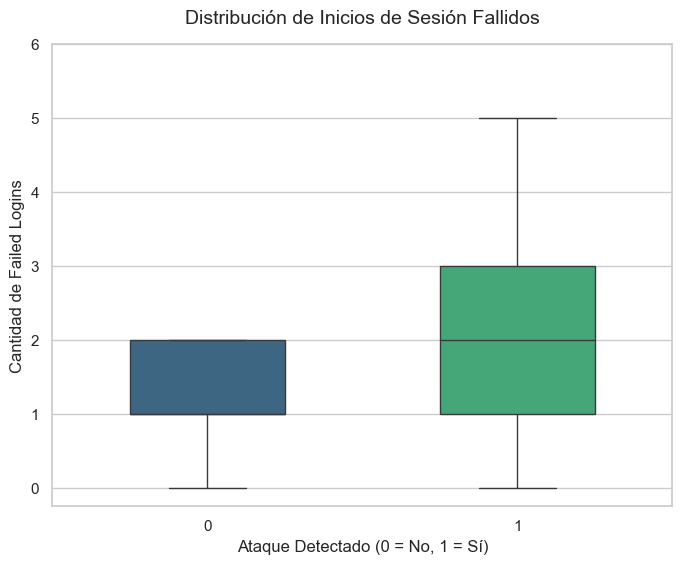

In [19]:
# 1. Configurar un estilo visual más limpio
sns.set_theme(style="whitegrid")

# 2. Crear la figura con un tamaño adecuado
plt.figure(figsize=(8, 6))

# 3. Graficar con mejoras: 
# - 'palette' para diferenciar los grupos
# - 'hue' para asignar colores según la categoría
# - 'width' para ajustar el ancho de las cajas
ax = sns.boxplot(
    data=dfo, 
    x='attack_detected', 
    y='failed_logins', 
    hue='attack_detected',
    palette='viridis', 
    width=0.5,
    legend=False
)

# 4. Personalizar textos y etiquetas
plt.title('Distribución de Inicios de Sesión Fallidos', fontsize=14, pad=15)
plt.xlabel('Ataque Detectado (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Failed Logins', fontsize=12)

# Opcional: Ajustar los ticks del eje Y para que coincidan con tus datos (0 a 5)
plt.yticks(range(0, 7))

plt.show()


In [20]:
dfo[['failed_logins', 'login_attempts', 'ip_reputation_score', 'unusual_time_access', 'attack_detected']].corr()

,failed_logins,login_attempts,ip_reputation_score,unusual_time_access,attack_detected
failed_logins,1.000000,-0.018116,0.014806,0.010292,0.367502
login_attempts,-0.018116,1.000000,-0.000042,0.017995,0.276770
ip_reputation_score,0.014806,-0.000042,1.000000,-0.009040,0.214994
unusual_time_access,0.010292,0.017995,-0.009040,1.000000,0.004853
attack_detected,0.367502,0.276770,0.214994,0.004853,1.000000


In [21]:
dfo.groupby('attack_detected')['ip_reputation_score'].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,4217.0,0.296631,0.147632,0.007030,0.176880,0.291941,0.411859,0.599409
1,3354.0,0.373646,0.201954,0.002497,0.210324,0.347468,0.531332,0.924299


La variable ip_reputation_score refleja el nivel de confiabilidad de las direcciones IP que interactúan con el sistema. En el dataset analizado, las direcciones IP con puntuaciones más altas muestran mayor asociación con sesiones clasificadas como ataques. Este comportamiento sugiere que la reputación de IP constituye un indicador relevante para identificar tráfico potencialmente malicioso. Desde una perspectiva gerencial, este hallazgo respalda la implementación de mecanismos de filtrado basados en reputación de IP para fortalecer los controles de acceso y prevenir intrusiones.

C:\Users\Rivera\AppData\Local\Temp\ipykernel_16228\3392974714.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


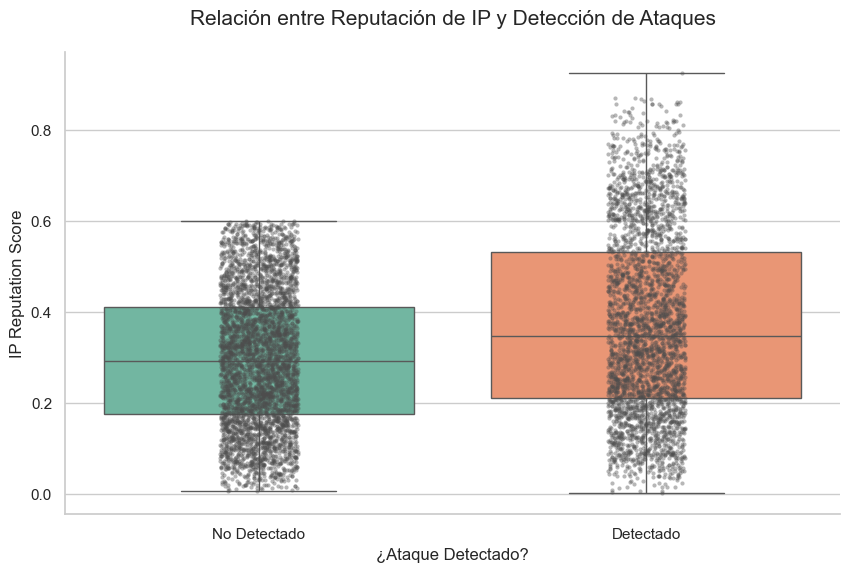

In [23]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear el boxplot con colores personalizados
ax = sns.boxplot(
    data=dfo, 
    x='attack_detected', 
    y='ip_reputation_score', 
    palette="Set2", 
    showfliers=False  # Oculta outliers para no ensuciar si hay muchos
)

# Añadir los puntos individuales (opcional, da mucho contexto)
sns.stripplot(
    data=dfo, 
    x='attack_detected', 
    y='ip_reputation_score', 
    color=".3", 
    alpha=0.4, 
    size=3
)

# Mejorar textos y etiquetas
plt.title("Relación entre Reputación de IP y Detección de Ataques", fontsize=15, pad=20)
plt.xlabel("¿Ataque Detectado?", fontsize=12)
plt.ylabel("IP Reputation Score", fontsize=12)
plt.xticks([0, 1], ['No Detectado', 'Detectado']) # Mejora legibilidad del eje X

sns.despine() # Quita los bordes innecesarios
plt.show()


## Lo más relevante es que el grupo naranja muestra una dispersión mucho mayor hacia puntajes de reputación altos (hasta 0.9).
## Conclusión clave: No se puede confiar ciegamente en una "buena reputación" (puntaje alto), ya que hay muchos ataques detectados provenientes de ## IPs que parecen seguras.


In [33]:

dfo['attack_detected'].value_counts(normalize=True)

attack_detected
0    0.556994
1    0.443006
Name: proportion, dtype: float64

## Si una proporción significativa de las sesiones corresponde a ataques detectados, esto sugiere un entorno de red con alta exposición a amenazas, lo que refuerza la necesidad de implementar mecanismos automatizados de detección y respuesta.
## La variable attack_detected constituye el elemento central del análisis, ya que permite identificar y clasificar las sesiones de red según su nivel de riesgo. Al tratarse de una variable binaria, facilita el desarrollo de modelos de aprendizaje automático supervisado capaces de reconocer patrones asociados con ataques. Este enfoque permite anticipar comportamientos maliciosos y fortalecer las capacidades de detección temprana dentro de los sistemas de seguridad.